<a href="https://colab.research.google.com/github/21anirudh/Data-Preprocessing-And-Feature-Engineering/blob/main/LoanApprovalPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [287]:
# Necessary Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans, DBSCAN

In [288]:
# Importing dataset

train_data = pd.read_csv('Training Dataset.csv')
test_data = pd.read_csv('Test Dataset.csv')

In [289]:
# handling missing values

train_data['LoanAmount'].fillna(train_data['LoanAmount'].mean(), inplace=True)
test_data['LoanAmount'].fillna(test_data['LoanAmount'].mean(), inplace=True)

for column in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents','Loan_Amount_Term','Credit_History']:
    train_data[column].fillna(train_data[column].mode()[0], inplace=True)
    test_data[column].fillna(test_data[column].mode()[0], inplace=True)

print("Remaining NaN values in training data:")
print(train_data.isnull().sum())

print("Remaining NaN values in test data:")
print(test_data.isnull().sum())

Remaining NaN values in training data:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
Remaining NaN values in test data:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [290]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables
label_encoder = LabelEncoder()
for column in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']:
    train_data[column] = label_encoder.fit_transform(train_data[column])
    test_data[column] = label_encoder.transform(test_data[column])

train_data['Dependents'] = train_data['Dependents'].replace('3+', 3).astype(int)
test_data['Dependents'] = test_data['Dependents'].replace('3+', 3).astype(int)


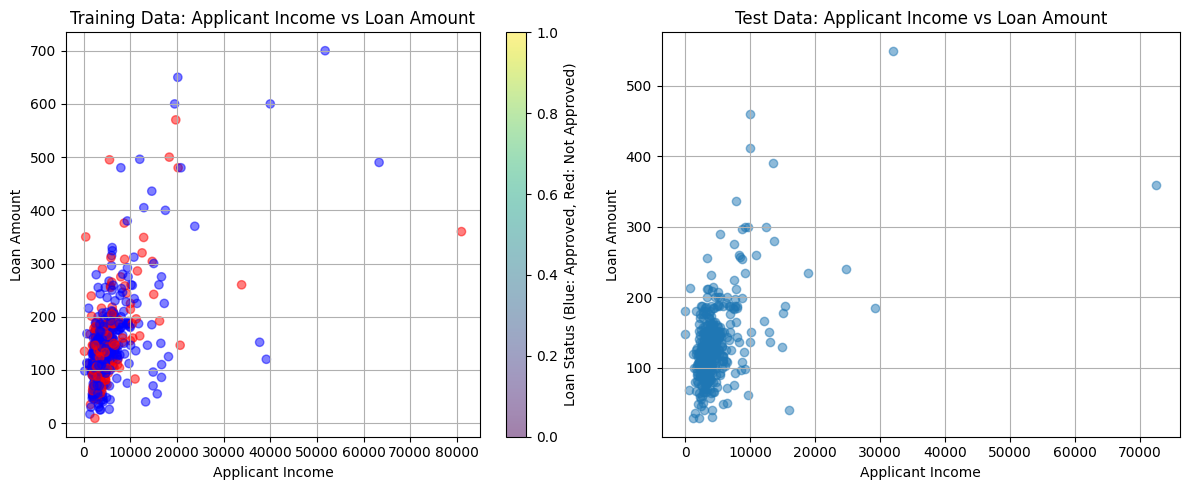

In [291]:
train_colors = np.where(train_data['Loan_Status'] == 'Y', 'blue', 'red')

plt.figure(figsize=(12, 5))

# Plot for Training Data
plt.subplot(1, 2, 1)
plt.scatter(train_data['ApplicantIncome'], train_data['LoanAmount'],
            c=train_colors, alpha=0.5)
plt.title('Training Data: Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.colorbar(label='Loan Status (Blue: Approved, Red: Not Approved)')
plt.grid()

# Plot for Test Data
plt.subplot(1, 2, 2)
plt.scatter(test_data['ApplicantIncome'], test_data['LoanAmount'], alpha=0.5)
plt.title('Test Data: Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.grid()

plt.tight_layout()
plt.show()

In [292]:
features = ['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome',
            'CoapplicantIncome', 'LoanAmount', 'Credit_History', 'Dependents']
X = train_data[features]
y = train_data['Loan_Status']

# Splitting the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = test_data[features]

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


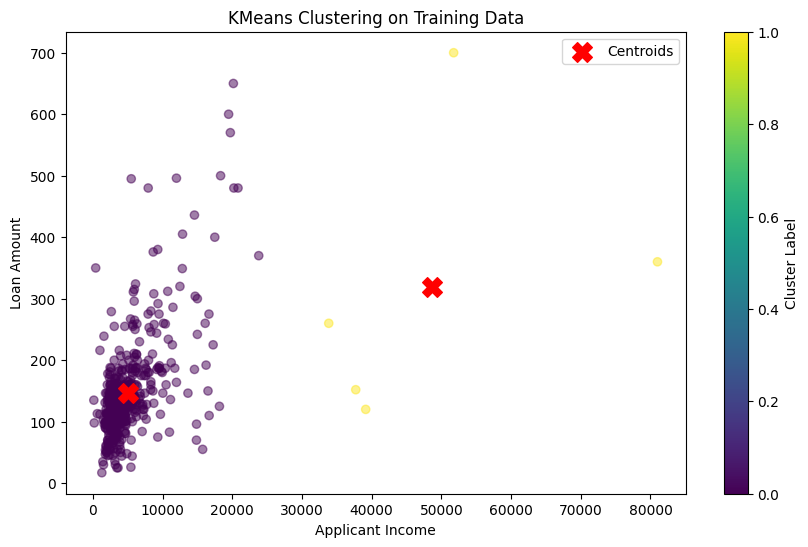

In [293]:
# Applying KMeans Clustering

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit_predict(X_train)

# Plotting KMeans results
plt.figure(figsize=(10, 6))
plt.scatter(X_train['ApplicantIncome'], X_train['LoanAmount'],
            c=kmeans.labels_, cmap='viridis', alpha=0.5)

centroids = kmeans.cluster_centers_[:, [4, 6]]  # selecting income and loan amount for centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title('KMeans Clustering on Training Data')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.colorbar(label='Cluster Label')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


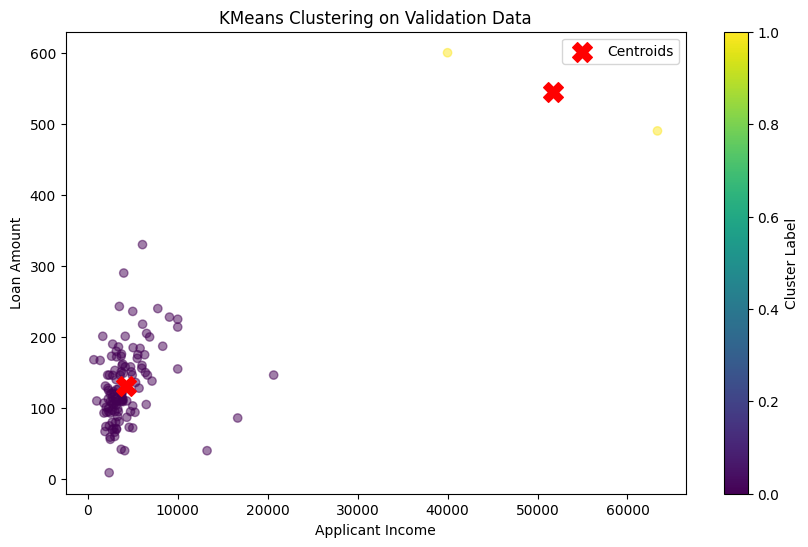

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


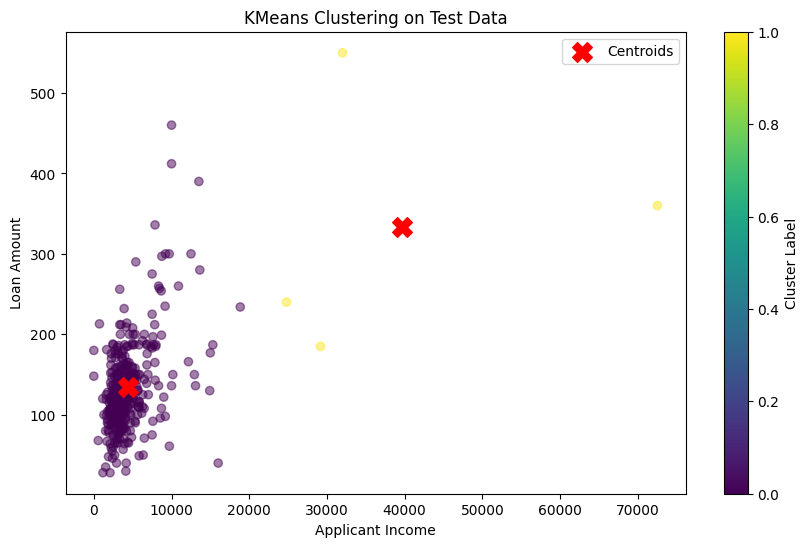

In [294]:
# KMeans for validation and testing data

# Validation Set



kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit_predict(X_val)

# Plotting KMeans results
plt.figure(figsize=(10, 6))
plt.scatter(X_val['ApplicantIncome'], X_val['LoanAmount'],
            c=kmeans.labels_, cmap='viridis', alpha=0.5)

centroids = kmeans.cluster_centers_[:, [4, 6]]  # selecting income and loan amount for centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title('KMeans Clustering on Validation Data')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.colorbar(label='Cluster Label')
plt.legend()
plt.show()




# Test Set



kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit_predict(X_test)

# Plotting KMeans results
plt.figure(figsize=(10, 6))
plt.scatter(X_test['ApplicantIncome'], X_test['LoanAmount'],
            c=kmeans.labels_, cmap='viridis', alpha=0.5)

centroids = kmeans.cluster_centers_[:, [4, 6]]  # selecting income and loan amount for centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title('KMeans Clustering on Test Data')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.colorbar(label='Cluster Label')
plt.legend()
plt.show()

<ipython-input-295-520044b7280d>:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_train['ApplicantIncome'][dbscan_labels == label],


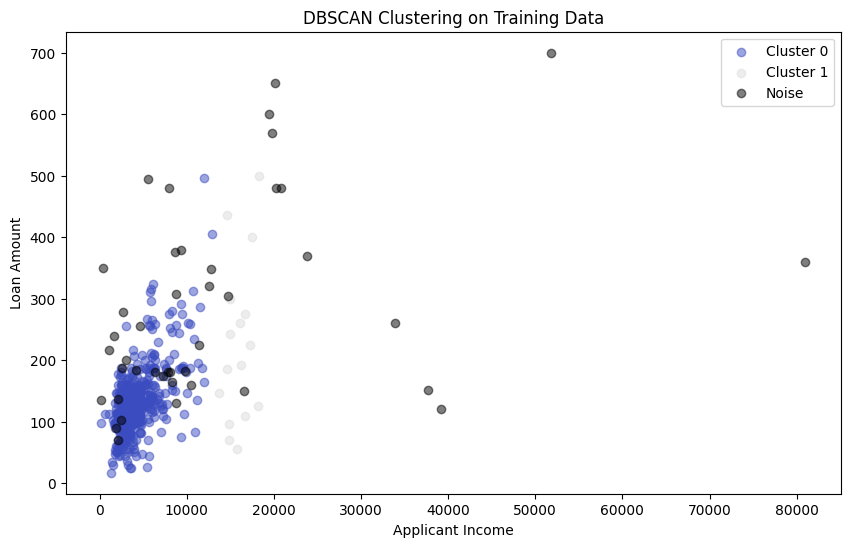

In [295]:
# Applying DBSCAN Clustering

dbscan = DBSCAN(eps=1000, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_train)

# Plotting DBSCAN results
plt.figure(figsize=(10, 6))
unique_labels = set(dbscan_labels)

colors = plt.cm.coolwarm(np.linspace(0, 1, len(unique_labels)))

for label in unique_labels:
    if label == -1:
        color = 'black'  # Noise points
    else:
        color = colors[label]

    plt.scatter(X_train['ApplicantIncome'][dbscan_labels == label],
                X_train['LoanAmount'][dbscan_labels == label],
                c=color, label=f'Cluster {label}' if label != -1 else 'Noise', alpha=0.5)

plt.title('DBSCAN Clustering on Training Data')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.legend()
plt.show()

<ipython-input-296-f87ea2452634>:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_val['ApplicantIncome'][dbscan_val == label],


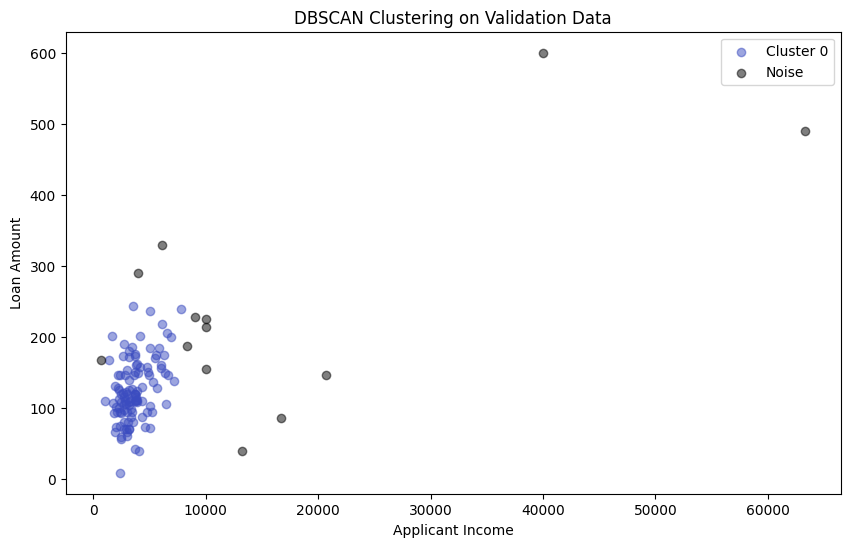

<ipython-input-296-f87ea2452634>:57: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_test['ApplicantIncome'][dbscan_test == label],


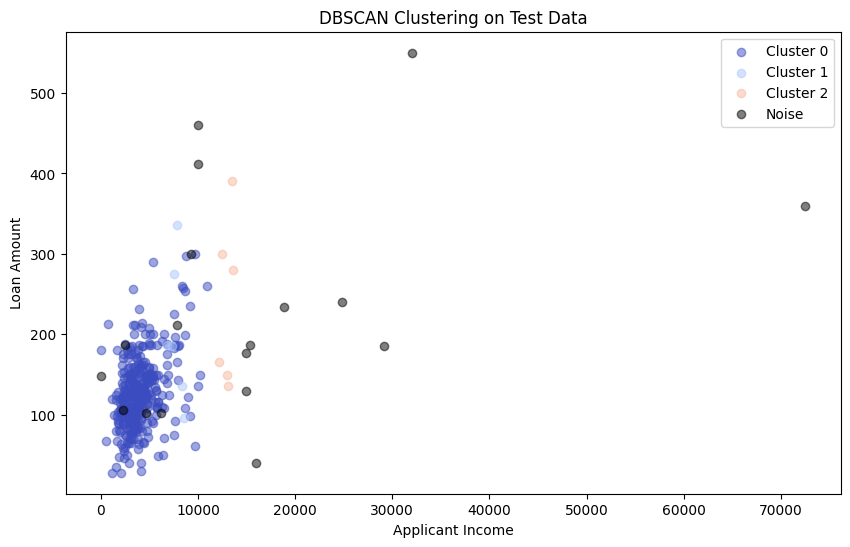

In [296]:
# DBSCAN for validation and testing data

# Validation Set



# Predicting clusters for test data using DBSCAN
dbscan_val = dbscan.fit_predict(X_val)

# Plotting DBSCAN results for test data
plt.figure(figsize=(10, 6))
unique_labels = set(dbscan_val)

# Creating a color map for clusters
colors = plt.cm.coolwarm(np.linspace(0, 1, len(unique_labels)))

for label in unique_labels:
    if label == -1:
        color = 'black'  # Noise points
    else:
        color = colors[label]

    plt.scatter(X_val['ApplicantIncome'][dbscan_val == label],
                X_val['LoanAmount'][dbscan_val == label],
                c=color, label=f'Cluster {label}' if label != -1 else 'Noise', alpha=0.5)

plt.title('DBSCAN Clustering on Validation Data')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.legend()
plt.show()





# Test Set



# Predicting clusters for test data using DBSCAN
dbscan_test = dbscan.fit_predict(X_test)

# Plotting DBSCAN results for test data
plt.figure(figsize=(10, 6))
unique_labels = set(dbscan_test)

# Creating a color map for clusters
colors = plt.cm.coolwarm(np.linspace(0, 1, len(unique_labels)))

for label in unique_labels:
    if label == -1:
        color = 'black'  # Noise points
    else:
        color = colors[label]

    plt.scatter(X_test['ApplicantIncome'][dbscan_test == label],
                X_test['LoanAmount'][dbscan_test == label],
                c=color, label=f'Cluster {label}' if label != -1 else 'Noise', alpha=0.5)

plt.title('DBSCAN Clustering on Test Data')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.legend()
plt.show()

In [351]:
knn = KNeighborsClassifier(n_neighbors=100, weights='distance', algorithm='auto') # weights = distance as it favors the closest neighbor -- improved accuract from 55 to 65
rf = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_split=3, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [352]:
knn.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [353]:
print("Training Set Evaluation:\n")
print("KNN Accuracy:", accuracy_score(y_val, knn.predict(X_val)))
print("Random Forest Accuracy:", accuracy_score(y_val, rf.predict(X_val)))
print("Gradient Boosting Accuracy:", accuracy_score(y_val, gb.predict(X_val)))

Training Set Evaluation:

KNN Accuracy: 0.6504065040650406
Random Forest Accuracy: 0.7886178861788617
Gradient Boosting Accuracy: 0.7642276422764228
